# Instagram Personal Data Report

**Name:** Sara  Virgüez Calderón
**Date:** September 23, 2026

## Data Source

The source of this data is my personal Instagram account. The data was collected and organized by Instagram, but it was created through my own activity and the way I interact with content on the platform.

For this report, I chose the `story_likes.json` file because it contains information about the stories I have liked on Instagram. The file includes information such as when the interaction happened and details about the account that posted the story. This makes the data useful for looking at which accounts I interact with the most through story likes and whether those interactions are mainly with people I know in real life or with influencers and public accounts.

I think the data can be considered reliable because it comes directly from Instagram and records actions made through my account instead of depending on what I remember doing. At the same time, there are some limitations. The data can show which accounts received my story likes and when those interactions happened, but it does not explain why I liked a specific story. It also does not identify whether an account belongs to someone I know personally or to an influencer or public figure, so that distinction has to be made separately during the analysis.

## Hypothesis


My hypothesis is that among the 10 accounts I give the most story likes to on Instagram, most will be people I know in real life rather than influencers, celebrities, or people I only know through social media. I also expect the frequency of my interactions within these top accounts to be higher for people I personally know.

The idea behind this hypothesis comes from the way I normally use Instagram. Even though I follow and see content from influencers and public accounts, I believe I am more likely to actively interact with stories posted by friends or people I have met in real life.

To test this statistically, I will identify the 10 accounts that received the highest number of story likes from me and classify them as either `Person I Know` or `Influencer/Public Account`. I can then compare how many accounts belong to each category and the total number of story likes received by each group. If people I know represent most of the top 10 accounts and receive a higher number of likes within this group, the results would support my hypothesis.

In [27]:
import json
import pandas as pd

with open('story_likes.json', 'r') as f:
    data = json.load(f)
data[0]

{'timestamp': 1789265782,
 'media': [],
 'label_values': [{'label': 'URL',
   'value': 'https://www.instagram.com/stories/sandra.llanos.56/3984880945949741041',
   'href': 'https://www.instagram.com/stories/sandra.llanos.56/3984880945949741041'},
  {'dict': [], 'title': 'Hashtags'},
  {'dict': [{'dict': [{'label': 'URL', 'value': ''},
      {'label': 'Name', 'value': 'Sandra Llanos'},
      {'label': 'Username', 'value': 'sandra.llanos.56'}],
     'title': ''}],
   'title': 'Owner'},
  {'dict': [], 'title': 'Brand partner'}],
 'fbid': '17974399740133422'}

In [28]:
df = pd.DataFrame(data)

df.head(10)

,timestamp,media,label_values,fbid
0,1789265782,[],"[{'label': 'URL', 'value': 'https://www.instag...",17974399740133422
1,1789249169,[],"[{'label': 'URL', 'value': 'https://www.instag...",18117087262988126
2,1789247604,[],"[{'label': 'URL', 'value': 'https://www.instag...",18127954681690045
3,1789078551,[],"[{'label': 'URL', 'value': 'https://www.instag...",18430432372180312
4,1789072079,[],"[{'label': 'URL', 'value': 'https://www.instag...",18071370329754040
5,1789064015,[],"[{'label': 'URL', 'value': 'https://www.instag...",17957339895214509
6,1789051386,[],"[{'label': 'URL', 'value': 'https://www.instag...",17932528191400595
7,1789006238,[],"[{'label': 'URL', 'value': 'https://www.instag...",17910145845287684
8,1788982595,[],"[{'label': 'URL', 'value': 'https://www.instag...",18097269611529289
9,1788971715,[],"[{'label': 'URL', 'value': 'https://www.instag...",17955885573212336


In [29]:
df['label_values'][0]

[{'label': 'URL',
  'value': 'https://www.instagram.com/stories/sandra.llanos.56/3984880945949741041',
  'href': 'https://www.instagram.com/stories/sandra.llanos.56/3984880945949741041'},
 {'dict': [], 'title': 'Hashtags'},
 {'dict': [{'dict': [{'label': 'URL', 'value': ''},
     {'label': 'Name', 'value': 'Sandra Llanos'},
     {'label': 'Username', 'value': 'sandra.llanos.56'}],
    'title': ''}],
  'title': 'Owner'},
 {'dict': [], 'title': 'Brand partner'}]

In [30]:
df['label_values'][0][2]['dict'][0]['dict'][2]['value']

'sandra.llanos.56'

In [31]:
def get_username(label_values):
    for item in label_values:
        if item.get('title') == 'Owner':
            owner_data = item.get('dict', [])
            if owner_data:
                for detail in owner_data[0].get('dict', []):
                    if detail.get('label') == 'Username':
                        return detail.get('value')
    return None

df['Username'] = df['label_values'].apply(get_username)

df.head(10)

,timestamp,media,label_values,fbid,Username
0,1789265782,[],"[{'label': 'URL', 'value': 'https://www.instag...",17974399740133422,sandra.llanos.56
1,1789249169,[],"[{'label': 'URL', 'value': 'https://www.instag...",18117087262988126,mariana_quin22
2,1789247604,[],"[{'label': 'URL', 'value': 'https://www.instag...",18127954681690045,paulaa_vidaal
3,1789078551,[],"[{'label': 'URL', 'value': 'https://www.instag...",18430432372180312,rubigol
4,1789072079,[],"[{'label': 'URL', 'value': 'https://www.instag...",18071370329754040,consubecerraa
5,1789064015,[],"[{'label': 'URL', 'value': 'https://www.instag...",17957339895214509,eduardogm18
6,1789051386,[],"[{'label': 'URL', 'value': 'https://www.instag...",17932528191400595,anaamezquita1204
7,1789006238,[],"[{'label': 'URL', 'value': 'https://www.instag...",17910145845287684,eduardogm18
8,1788982595,[],"[{'label': 'URL', 'value': 'https://www.instag...",18097269611529289,consubecerraa
9,1788971715,[],"[{'label': 'URL', 'value': 'https://www.instag...",17955885573212336,soofia__gll


In [32]:
df['Date'] = pd.to_datetime(df['timestamp'], unit='s')

df.head(10)

,timestamp,media,label_values,fbid,Username,Date
0,1789265782,[],"[{'label': 'URL', 'value': 'https://www.instag...",17974399740133422,sandra.llanos.56,2026-09-13 02:16:22
1,1789249169,[],"[{'label': 'URL', 'value': 'https://www.instag...",18117087262988126,mariana_quin22,2026-09-12 21:39:29
2,1789247604,[],"[{'label': 'URL', 'value': 'https://www.instag...",18127954681690045,paulaa_vidaal,2026-09-12 21:13:24
3,1789078551,[],"[{'label': 'URL', 'value': 'https://www.instag...",18430432372180312,rubigol,2026-09-10 22:15:51
4,1789072079,[],"[{'label': 'URL', 'value': 'https://www.instag...",18071370329754040,consubecerraa,2026-09-10 20:27:59
5,1789064015,[],"[{'label': 'URL', 'value': 'https://www.instag...",17957339895214509,eduardogm18,2026-09-10 18:13:35
6,1789051386,[],"[{'label': 'URL', 'value': 'https://www.instag...",17932528191400595,anaamezquita1204,2026-09-10 14:43:06
7,1789006238,[],"[{'label': 'URL', 'value': 'https://www.instag...",17910145845287684,eduardogm18,2026-09-10 02:10:38
8,1788982595,[],"[{'label': 'URL', 'value': 'https://www.instag...",18097269611529289,consubecerraa,2026-09-09 19:36:35
9,1788971715,[],"[{'label': 'URL', 'value': 'https://www.instag...",17955885573212336,soofia__gll,2026-09-09 16:35:15


In [33]:
tidy_df = df[['Username', 'Date']].copy()

tidy_df.head(10)

,Username,Date
0,sandra.llanos.56,2026-09-13 02:16:22
1,mariana_quin22,2026-09-12 21:39:29
2,paulaa_vidaal,2026-09-12 21:13:24
3,rubigol,2026-09-10 22:15:51
4,consubecerraa,2026-09-10 20:27:59
5,eduardogm18,2026-09-10 18:13:35
6,anaamezquita1204,2026-09-10 14:43:06
7,eduardogm18,2026-09-10 02:10:38
8,consubecerraa,2026-09-09 19:36:35
9,soofia__gll,2026-09-09 16:35:15


## Tidy DataFrame

This DataFrame gives me a simpler way to look at my Instagram story likes. Each row represents a story that I liked, and the columns show the username of the account and the date when the like happened.

I organized it this way because it makes the information easier to read and analyze. Each row focuses on one interaction, and the username and date are kept as separate variables. This also makes it easier for me to group the data by username and see which accounts I interact with more frequently.

This DataFrame helps me start testing my hypothesis because I can see which accounts received the most likes from me. However, Instagram does not tell me if I know the person in real life or if the account belongs to an influencer or public figure, so I still need to classify that information myself.

In [34]:
tidy_df.groupby('Username').count()

,Date
Username,
_sorcal,15
a_gonidakis7,5
aina.cardell,1
alejandraurreaa,2
alonsolopez_21,1
amayaelizabeth_,3
anaamezquita1204,43
anaamezquita_privvvvvvvv,21
andregcalderon,42


In [35]:
likes_by_account = tidy_df.groupby('Username').count()

likes_by_account = likes_by_account.rename(
    columns={'Date': 'Number of Story Likes'}
)

likes_by_account = likes_by_account.sort_values(
    by='Number of Story Likes',
    ascending=False
)

likes_by_account.head(10)

,Number of Story Likes
Username,
soofia__gll,236
eduardogm18,119
anaamezquita1204,43
andregcalderon,42
anaamezquita_privvvvvvvv,21
nicolebta,16
_sorcal,15
isabella.ladera,12
marianainfanteb,11


In [36]:
pd.set_option('display.max_rows', None)

likes_by_account

,Number of Story Likes
Username,
soofia__gll,236
eduardogm18,119
anaamezquita1204,43
andregcalderon,42
anaamezquita_privvvvvvvv,21
nicolebta,16
_sorcal,15
isabella.ladera,12
marianainfanteb,11


In [37]:
public_accounts = [
    'nicolebta',
    'isabella.ladera',
    'marianainfanteb',
    'sofiasurfers',
    'consubecerraa',
    'lolalolita',
    'maluma',
    'manuelaqm__',
    'westcol',
    'isabellaaa0902',
    'karolg',
    'ongarato_o',
    'paulaa_vidaal',
    'yanblockpr',
    'hudabubbaaa',
    'jess.judith',
    'amayaelizabeth_',
    'danielaaoliverr',
    'rubigol',
    'blessd',
    'kentstatechicks',
    'is4belcalvo',
    'alejandraurreaa',
    'isaissa111',
    'leticia.alepuz',
    'alonsolopez_21',
    'vickyguez_',
    'aina.cardell',
    'kateli',
    'pensamientosaldesnudo_',
    'palomamami',
    'ester_exposito',
    'mariana_varela_',
    'isabellalondono1',
    'laurapons29',
    'mariaantoniachica_',
    'labelliido'
]

likes_by_account['Account Type'] = [
    'Influencer/Public Account' if username in public_accounts
    else 'Person I Know'
    for username in likes_by_account.index
]

likes_by_account.head(10)

,Number of Story Likes,Account Type
Username,,
soofia__gll,236,Person I Know
eduardogm18,119,Person I Know
anaamezquita1204,43,Person I Know
andregcalderon,42,Person I Know
anaamezquita_privvvvvvvv,21,Person I Know
nicolebta,16,Influencer/Public Account
_sorcal,15,Person I Know
isabella.ladera,12,Influencer/Public Account
marianainfanteb,11,Influencer/Public Account


### Classifying the Accounts

To test my hypothesis, I needed to separate the accounts into two categories: people I know in real life and influencers or public accounts. The original Instagram data does not provide information about my personal relationship with each account, so this classification could not be taken directly from the JSON file.

I classified the 10 accounts with the highest number of story likes based on whether I personally know the person behind the account. I added an `Account Type` column to identify each account as either `Person I Know` or `Influencer/Public Account`. This allows me to compare not only which accounts receive the most story likes from me, but also whether the overall frequency of my likes is higher for people I know personally or for public accounts.

In [38]:
top_10 = likes_by_account.head(10)

likes_by_type = top_10.groupby('Account Type')['Number of Story Likes'].sum()

likes_by_type

Account Type
Influencer/Public Account     39
Person I Know                487
Name: Number of Story Likes, dtype: int64

### Comparing Story Likes by Account Type

After classifying the accounts, I grouped them by `Account Type` and added the number of story likes in each category. This allows me to directly compare how often I interact with people I know in real life versus influencers or public accounts within my top 10.

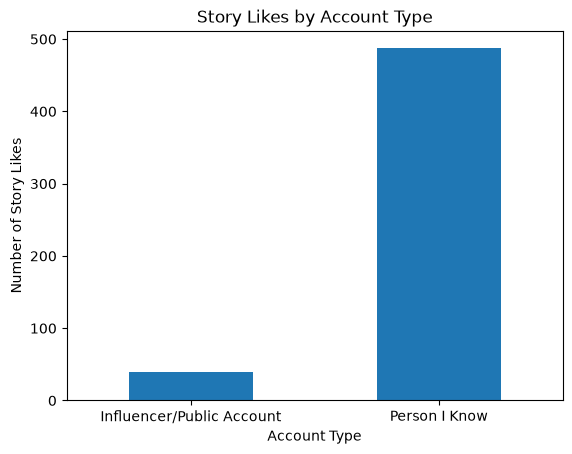

In [39]:
import matplotlib.pyplot as plt

likes_by_type.plot(kind='bar')

plt.title('Story Likes by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Number of Story Likes')
plt.xticks(rotation=0)
plt.show()

## Results and Conclusion

After comparing the two categories, I found that people I know in real life received 487 story likes within my top 10 accounts, while influencers or public accounts received only 39. This means that about 92.6% of the likes in this group went to people I know personally, compared to 7.4% that went to influencers or public accounts.

This supports my hypothesis because I expected most of my frequent story interactions to be with people I know in real life. Even though influencers and public accounts are still part of my Instagram activity, the difference in the number of likes shows that I interact much more frequently with people I personally know.

Something important to consider is that I only analyzed my top 10 accounts. Because of this, these results describe my most frequent interactions, but they do not necessarily represent every account in my complete story likes data.

## Reflection

Throughout this project, I used AI as a tool to help me make some of the coding steps more concise and to better understand how I could organize the data to answer my questions. For example, AI helped me understand how to convert the timestamp into a readable date, group the accounts based on the number of story likes, and eventually sort them from the accounts I interacted with the most to the least.

At the beginning, I explored the data by looking at the accounts and the number of likes associated with each one. As I continued working with the JSON file, I was able to understand the structure of the data better and decide which information was actually useful for my project. 

Working through the different steps allowed me to develop my own analysis of the data. I had to decide what I wanted to investigate, classify which accounts belonged to people I know personally and which belonged to influencers or public accounts, and interpret what the final results meant. By working with the JSON data and making these decisions throughout the process, I was able to create a clearer direction for the project and use the data to test my proposed hypothesis.

## Limitations and Next Steps

One thing to consider about this analysis is that I only classified my top 10 accounts instead of all the accounts in the dataset. This made the project easier to manage, but it also means that my results only describe this specific group.

I also had to classify the accounts myself because Instagram does not tell me whether I personally know someone or if the account belongs to an influencer or public figure. Another limitation is that this file only shows the stories I liked. It does not show all the stories I viewed without liking, so I cannot use this data to determine how often I give likes compared to everything I see.

If I continued this analysis, I would classify all the accounts in the dataset to see if the same pattern continues beyond my top 10. I would also be interested in using the date information to see if the way I interact with stories changes over time.